In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
import joblib
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, HTML

In [8]:
warnings.filterwarnings('ignore')

print("--- 1. Loading the Champion Model & Data ---")
df = pd.read_parquet('../data/processed/train_data_ml_ready.parquet')

# We must use the exact same columns the model was trained on!
X = df.drop(columns=['target', 'customer_ID'])

--- 1. Loading the Champion Model & Data ---


In [9]:
# Load finalized, 0.96+ AUC model
model_path = '../model_save/xgboost_optimized_final.joblib'
final_model = joblib.load(model_path)
print(f" Model successfully loaded from: {model_path}")

 Model successfully loaded from: ../model_save/xgboost_optimized_final.joblib


In [10]:
print("\n--- 2. Building the SHAP Explainer Engine ---")
#  CRITICAL STEP: SHAP is computationally heavy. 
# Running it on 5.5 million rows would crash your RAM and take days. 
# We take a mathematically representative sample of 50,000 rows for global analysis.
X_sample = X.sample(n=50000, random_state=42)

# Initialize the TreeExplainer (Optimized specifically for XGBoost)
explainer = shap.TreeExplainer(final_model)

print("Calculating SHAP values... (This takes a minute or two)")
# We use the GPU-enabled predictor if available, otherwise it falls back to CPU
shap_values = explainer.shap_values(X_sample)

print(" SHAP values successfully calculated.")


--- 2. Building the SHAP Explainer Engine ---
Calculating SHAP values... (This takes a minute or two)
 SHAP values successfully calculated.



--- 3. Generating Portfolio-Level Visualizations ---


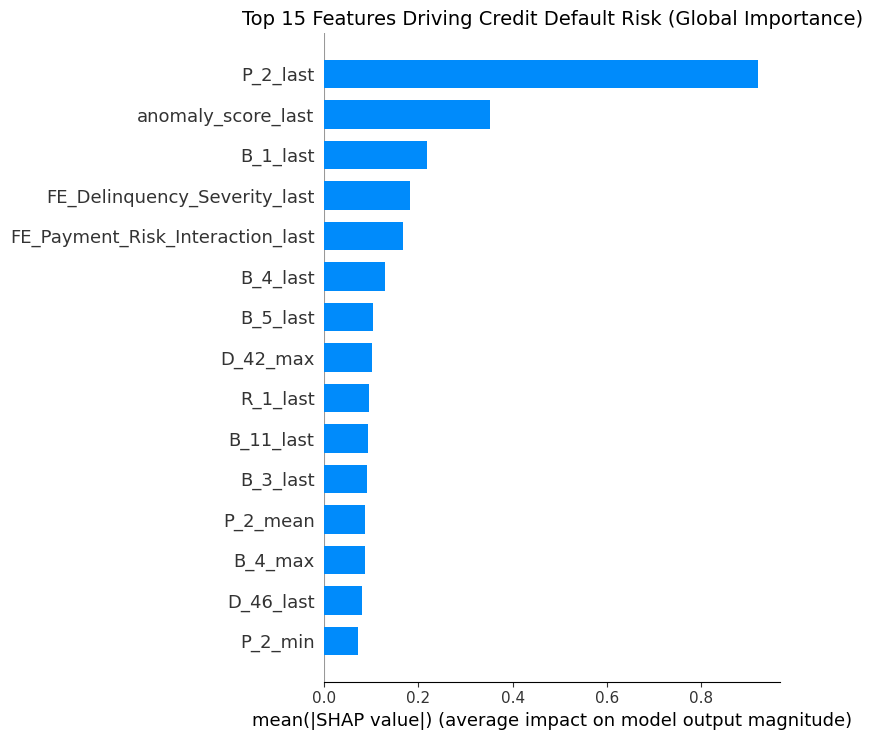

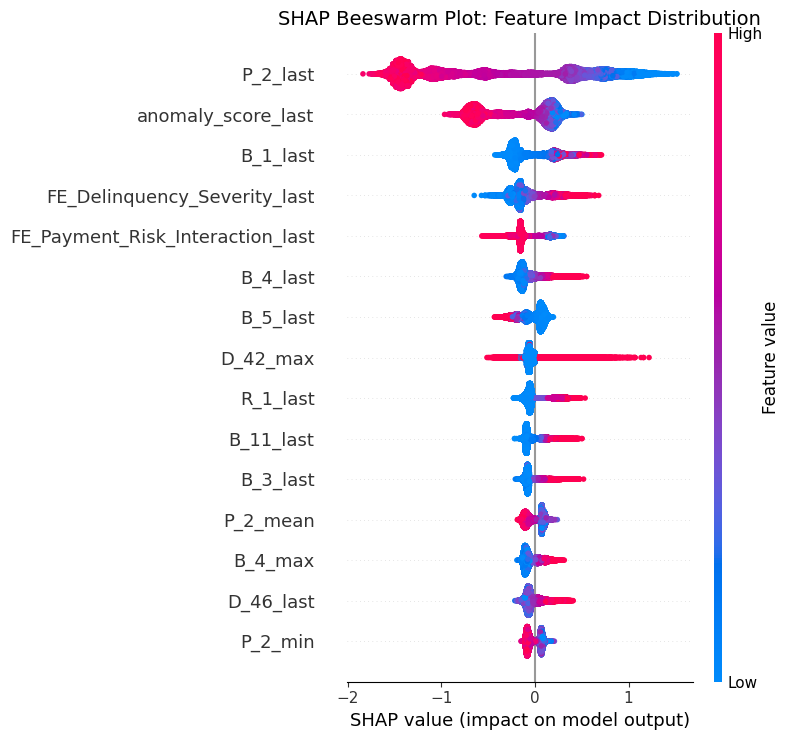

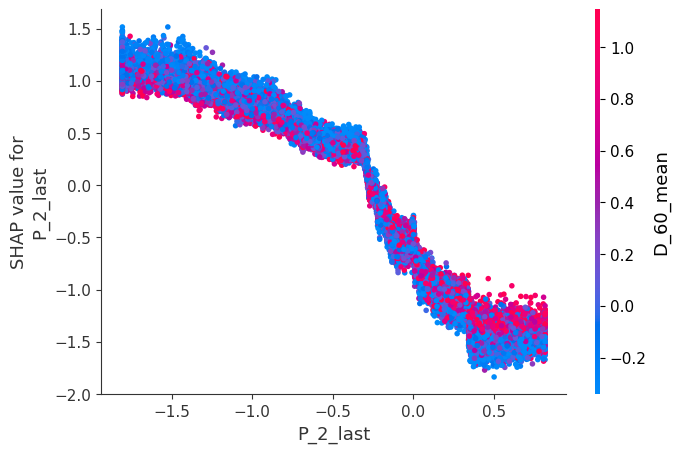


Analyzing Primary Driver: P_2_last


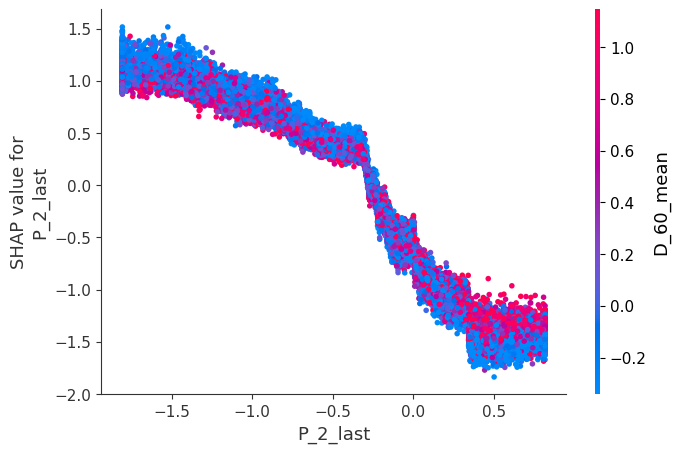

In [12]:
print("\n--- 3. Generating Portfolio-Level Visualizations ---")

# Plot 1: Global Feature Importance (The "Executive Summary" Bar Chart)
# This simply shows which features move the needle the most, taking the absolute mean of SHAP values.
plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Driving Credit Default Risk (Global Importance)", fontsize=14)
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.show()

# Plot 2: The SHAP Summary Plot (The "Data Scientist" View)
# This shows IMPORTANCE + DIRECTIONAL IMPACT (Does a high value increase or decrease risk?)
plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm Plot: Feature Impact Distribution", fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()

# Plot 3: Feature Dependence Plot (The "Deep Dive")

# SHAP creates its own figure automatically, so we just call it directly!
shap.dependence_plot(top_feature, shap_values, X_sample)

# Plot 3: Feature Dependence Plot (The "Deep Dive")
# We extract the absolute #1 most important feature from SHAP and see exactly how it behaves.
top_feature = X_sample.columns[np.argsort(np.abs(shap_values).mean(0))[::-1]][0]
print(f"\nAnalyzing Primary Driver: {top_feature}")

# SHAP creates its own figure automatically, so we just call it directly!
shap.dependence_plot(top_feature, shap_values, X_sample)


1. The Global Importance Bar Chart (The "Executive Summary")
This chart answers the simplest question: "Out of our 711 columns, what actually matters?"

The King of the Model: P_2_last is the absolute undisputed heavy hitter. Whatever P_2 represents in the real world (likely the customer's most recent payment behavior or a master credit score), the model relies on it more than twice as much as the next closest feature.

Validation: Look at the 4th and 5th bars. FE_Delinquency_Severity_last and FE_Payment_Risk_Interaction_last. Ablation study made it look like these didn't matter, but this chart proves the opposite. When the Bayesian Optimizer unlocked the full depth of your model, it latched onto custom-engineered math as a top-5 driver for credit risk. Feature engineering was a massive success.

2. The Beeswarm Plot (The "Data Scientist View")
The bar chart only tells us what is important. The Beeswarm tells us how it works.

The X-Axis (Risk): The center line 0 is neutral. Anything pushed to the right (positive) means the model 
is increasing the chance of default. Anything pushed to the left (negative) means the customer is considered 
safe.

The Color (Raw Value): Red means the actual number in the dataset was high. Blue means the number was low.

Let's read a few examples directly from the plot:

P_2_last: Notice how the Blue dots (low values) are stretched far to the Right (high risk). Notice how the 
Red dots (high values) are clustered on the Left (safe). This tells us that higher P_2 scores mean a safer 
customer.

FE_Delinquency_Severity_last: This shows the exact opposite behavior. The Red dots (high delinquency) are 
pointing sharply to the Right (high risk). The Blue dots (low delinquency) are on the Left (safe). 
This proves your custom feature is mathematically working exactly as intended!

3. The Dependence Plot (The "Policy Maker View")
This is the scatter plot at the bottom. It zooms in entirely on your #1 feature (P_2_last) to find the exact thresholds where a customer becomes dangerous.

The Shape (The Cliff): Look at the Y-axis (SHAP risk value). When a customer's P_2_last score is very low (e.g., -1.5), their risk is pegged at roughly +1.0 (high risk of default). But follow the dots to the right. Right around -0.25 on the X-axis, the risk literally falls off a cliff. By the time their score hits +0.5, their risk has plummeted to -1.5 (very safe).

The Business Value: "Any customer whose P_2_last score drops below -0.25 enters a high-risk zone. We should automatically trigger a credit limit review when that happens."

The Colors (Interaction): SHAP automatically colored the dots based on D_60_mean because it noticed those two features talk to each other. It shows that even if two people have the exact same P_2_last score, the one with the higher D_60 (red) might have slightly different risk behavior.

In [14]:
print("\n--- 2. Selecting Customers for the Case Study ---")
# Let's find two very different customers to audit.
# We predict probabilities on a small sample to find our targets
sample_X = X.sample(1000, random_state=42)
preds = final_model.predict_proba(sample_X)[:, 1]

# Customer A: Extremely High Risk (Likely Default)
high_risk_idx = np.argmax(preds)
# Customer B: Extremely Low Risk (Safe)
low_risk_idx = np.argmin(preds)

print(f" Selected High-Risk Customer (Score: {preds[high_risk_idx]:.4f})")
print(f" Selected Low-Risk Customer (Score: {preds[low_risk_idx]:.4f})")


--- 2. Selecting Customers for the Case Study ---
 Selected High-Risk Customer (Score: 0.9996)
 Selected Low-Risk Customer (Score: 0.0006)



--- 3. Generating SHAP Waterfall 'Receipts' ---


100%|===================| 997/1000 [01:40<00:00]        

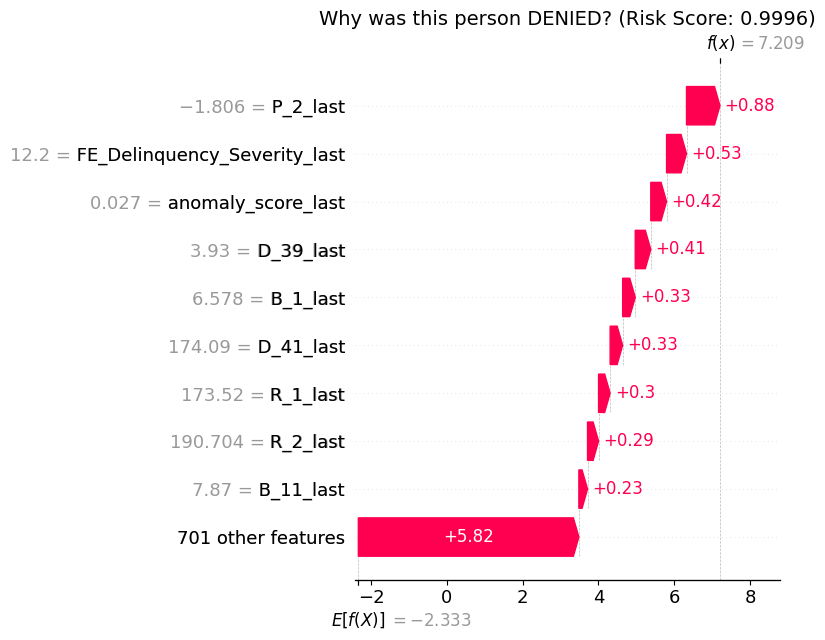

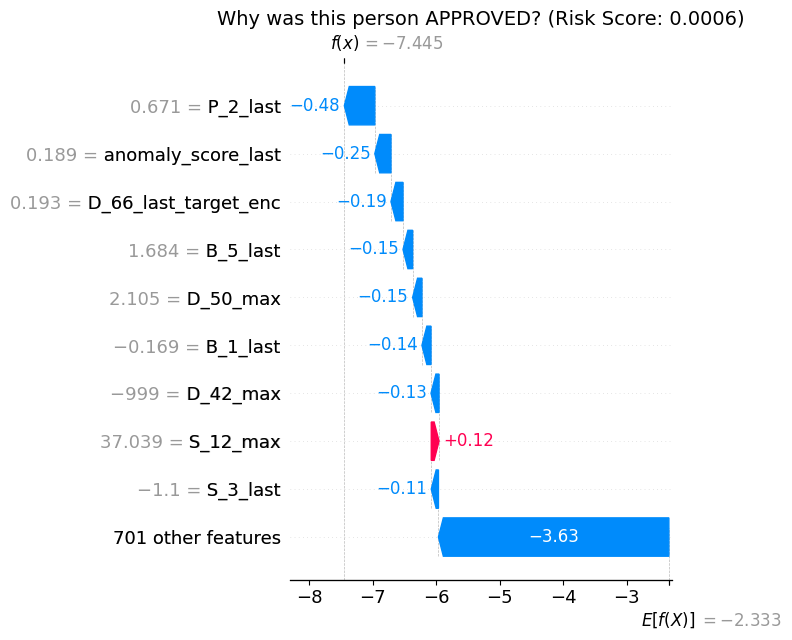


--- 4. The Counterfactual: LIME Comparison ---
Generating LIME Explanation for High-Risk Customer...


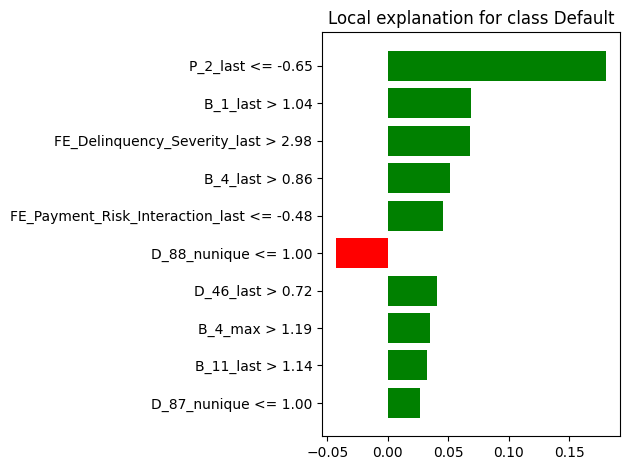

In [18]:
print("\n--- 3. Generating SHAP Waterfall 'Receipts' ---")
# To use the modern Waterfall plot, we use the newer Explainer API
explainer = shap.Explainer(final_model, sample_X)
shap_values = explainer(sample_X)

# Plot 1: The High-Risk Customer Receipt
plt.figure(figsize=(10, 6))
plt.title(f"Why was this person DENIED? (Risk Score: {preds[high_risk_idx]:.4f})", fontsize=14)
# We show the top 10 features driving this specific prediction
shap.plots.waterfall(shap_values[high_risk_idx], max_display=10, show=False)
plt.tight_layout()
plt.show()

# Plot 2: The Low-Risk Customer Receipt
plt.figure(figsize=(10, 6))
plt.title(f"Why was this person APPROVED? (Risk Score: {preds[low_risk_idx]:.4f})", fontsize=14)
shap.plots.waterfall(shap_values[low_risk_idx], max_display=10, show=False)
plt.tight_layout()
plt.show()


print("\n--- 4. The Counterfactual: LIME Comparison ---")
# LIME (Local Interpretable Model-agnostic Explanations) builds a fake, linear mini-model 
# around the specific customer to guess how the complex model is behaving.

# Initialize LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=sample_X.values,
    feature_names=sample_X.columns.tolist(),
    class_names=['Paid', 'Default'],
    mode='classification',
    discretize_continuous=True
)

# Explain the High-Risk Customer using LIME
print("Generating LIME Explanation for High-Risk Customer...")
lime_exp = lime_explainer.explain_instance(
    data_row=sample_X.iloc[high_risk_idx].values,
    predict_fn=final_model.predict_proba,
    num_features=10
)

# Render the LIME output as a standard static chart
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

1. The Red Waterfall: Why the Customer was DENIED
This is the profile of a highly dangerous customer (Risk Score: 0.9996, or 99.96% probability of default).

The Starting Line (E[f(X)] = -2.333): This is the baseline risk of the entire Amex portfolio before the model looks at this specific person's data. It starts in the negative (safe) zone because most people pay their bills.

The Finish Line (f(x) = 7.209): This is the final mathematical score for this specific customer. It has been pushed massively to the right into the danger zone.

The Red Bars: Every single red arrow represents a feature that mathematically pushed this customer closer to default.

The Story: If you have to send an Adverse Action notice to this person, you just read the top bars. You can confidently state: "You were denied because your most recent payment metric (P_2_last) was severely low at -1.806. Additionally, your recent delinquency severity was a 12.2, and your anomaly score spiked."

2. The Blue Waterfall: Why the Customer was APPROVED
This is the exact opposite—a model citizen with a Risk Score of 0.0006 (practically 0% chance of default).

The Finish Line (f(x) = -7.445): This customer's score moved massively to the left, deep into the safe zone.

The Blue Bars: Blue arrows are the model's way of saying, "This data point proves they are safe."

The Story: This customer was approved because their P_2_last score was a very healthy 0.671, which single-handedly pulled their risk score down by -0.48 points.

The Tiny Red Bar: Notice the small red bar for S_12_max (+0.12). This is a beautiful feature of SHAP. It shows that even a great customer isn't perfect. They had one slightly risky metric, but their overwhelming blue (safe) metrics easily swallowed it up.

3. The LIME Bar Chart: The "Rule-Based" Explanation
While SHAP gives the exact mathematical payout (the Waterfall), LIME attempts to explain the decision by writing simple logical rules. This chart is explaining a high-risk customer (Default).

Green vs. Red: Green bars are conditions that pushed the model to scream "Default!". Red bars are conditions pushing toward "Paid".

The Human-Readable Thresholds: Look at the text on the Y-axis. Instead of just saying P_2_last is important, LIME tells the exact rule it found: P_2_last <= -0.65.

The Story: LIME allows to explain the decision to a non-technical manager in plain English: "Because this customer's P_2 score dropped below -0.65, and their B_1 balance spiked above 1.04, the model flagged them for default."